<a href="https://colab.research.google.com/github/Sanika-tech123/Deep-Learning-Lab/blob/main/DL_4_Implementing_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully
Input Shape: (20640, 8)
Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.9130 - mae: 0.6374 - val_loss: 0.5008 - val_mae: 0.4977
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.4315 - mae: 0.4614 - val_loss: 0.4195 - val_mae: 0.4569
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3848 - mae: 0.4400 - val_loss: 0.4071 - val_mae: 0.4398
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.3606 - mae: 0.4262 - val_loss: 0.3801 - val_mae: 0.4358
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3485 - mae: 0.4169 - val_loss: 0.3738 - val_mae: 0.4259
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3325 - mae: 0.4074 - val_loss: 0.3795 - val_mae: 0.4208
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3301 - mae: 0.4049 - val_loss: 0.3721 - val_mae: 0.4097
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3468 - mae: 0.3962 - val_loss: 0.3401 - val_mae: 0.4051
Epoc

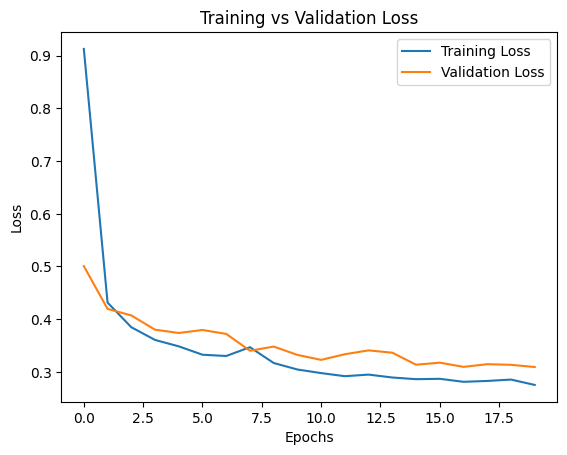

In [ ]:
# Import libraries
import tensorflow as tf
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Load Dataset
# ---------------------------------------------------

data = fetch_california_housing()

X = data.data
y = data.target

print("Dataset Loaded Successfully")
print("Input Shape:", X.shape)

# ---------------------------------------------------
# Train-Test Split
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------
# Feature Scaling
# ---------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------------------------------------------
# Build Deep Neural Network Model
# ---------------------------------------------------

model = tf.keras.Sequential([

    tf.keras.layers.Dense(64, activation='relu'),

    tf.keras.layers.Dense(32, activation='relu'),

    tf.keras.layers.Dense(1)
])

# ---------------------------------------------------
# Compile Model
# ---------------------------------------------------

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# ---------------------------------------------------
# Train Model
# ---------------------------------------------------

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_split=0.2
)

# ---------------------------------------------------
# Evaluate Model
# ---------------------------------------------------

loss, mae = model.evaluate(X_test, y_test)

print("\nTest Loss:", loss)
print("Test MAE:", mae)

# ---------------------------------------------------
# Make Prediction
# ---------------------------------------------------

prediction = model.predict(X_test[:5])

print("\nPredictions:")
print(prediction)

# ---------------------------------------------------
# Plot Graph
# ---------------------------------------------------

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()